## Sentiment Analysis using ML models

import required libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Text processing
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

load cleaned dataset

In [2]:
# Load the CSV file
df = pd.read_csv("C:\\Users\\92324\Desktop\\assesment\\sentiment_analysis_end_to_end\\src\\data\\cleaned_sentiment_dataset.csv")

# Display first few rows
df.head()

,review,sentiment,Clean_sentiment,Clean_review
0,Exploring the world of digital art. It's never...,neutral,neutral,exploring world digital art never late discove...
1,Feeling inspired after attending a workshop. ...,neutral,neutral,feeling inspired attending workshop
2,"Eyes wide open in the night, fearful shadows ...",neutral,neutral,eyes wide open night fearful shadows dancing w...
3,"A soul weathered by the storm of heartbreak, s...",neutral,neutral,soul weathered storm heartbreak seeking refuge...
4,"Attended a wine tasting event, savoring the ri...",neutral,neutral,attended wine tasting event savoring richness ...


 Feature Extraction and split

In [3]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95
)
X = tfidf.fit_transform(df['Clean_review'])
y = df['sentiment']

# Train/Test Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (640, 8652) Test shape: (160, 8652)


Traning and comparision different ML models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8562
Naive Bayes Accuracy: 0.8875
Linear SVM Accuracy: 0.8812
Random Forest Accuracy: 0.8375


Visual Comparision of Model Accuracies

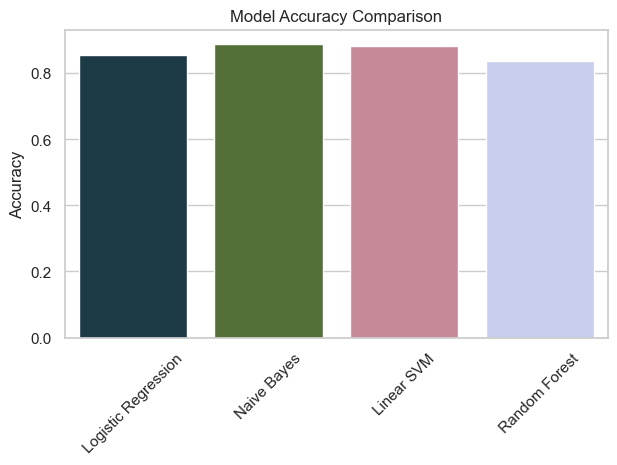


✅ Best Performing Model: Naive Bayes (88.75% accuracy)


In [5]:
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='cubehelix')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

best_model_name = max(results, key=results.get)
print(f"\n✅ Best Performing Model: {best_model_name} ({results[best_model_name]:.2%} accuracy)")

Detailed Evaluation of Best Model

In [6]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.92      0.85        51
     neutral       1.00      0.97      0.98        60
    positive       0.88      0.76      0.81        49

    accuracy                           0.89       160
   macro avg       0.89      0.88      0.88       160
weighted avg       0.89      0.89      0.89       160



Save Best Model and Vectorizer

In [7]:
joblib.dump(best_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n✅ Model and TF-IDF Vectorizer saved successfully!")


✅ Model and TF-IDF Vectorizer saved successfully!


Predict Sentiment on New Text

In [9]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text.strip()

df['Clean_review'] = df['review'].apply(clean_text)
df[['review', 'Clean_review']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\92324\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,Clean_review
0,Exploring the world of digital art. It's never...,exploring world digital art never late discove...
1,Feeling inspired after attending a workshop. ...,feeling inspired attending workshop
2,"Eyes wide open in the night, fearful shadows ...",eyes wide open night fearful shadows dancing w...
3,"A soul weathered by the storm of heartbreak, s...",soul weathered storm heartbreak seeking refuge...
4,"Attended a wine tasting event, savoring the ri...",attended wine tasting event savoring richness ...
5,"Despite meticulous training, the swimmer faces...",despite meticulous training swimmer faces disa...
6,Excited about the upcoming gaming tournament....,excited upcoming gaming tournament
7,Reflecting on personal growth achieved through...,reflecting personal growth achieved life exper...
8,Achieving a personal best in a track and field...,achieving personal best track field competitio...
9,Immersed in the pulsating beats of a Bruno Mar...,immersed pulsating beats bruno mars concert up...


In [ ]:
def predict_sentiment(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    pred = best_model.predict(vec)[0]
    return pred

# Example predictions
samples = [
    "It is ",
    "The service was amazing"
    
]

for s in samples:
    print(f"Text: {s} → sentiment: {predict_sentiment(s)}")

Text: It is  good → sentiment: negative
Text: The service was amazing → sentiment: neutral
